In [ ]:
%reload_ext autoreload
%autoreload 2


import iminuit
from fastfeedback import *
from tqdm import tqdm

# Loading the CAFs data

data_manager = DataManager("/storage/1/st15719/caf_new_sum_weighted.root")

# Defining the binning for the true and reco energy and coszenith
Ebins = np.logspace(-1, 1, 200)
Czbins = np.linspace(-1, 1, 100)
Ebins_reco = np.logspace(-1, 1, 50)
Czbins_reco = np.linspace(-1, 1, 20)

latex_names = {
    Flavor.NuE: r"$\nu_e$",
    Flavor.NuMu: r"$\nu_\mu$",
    Flavor.NuMuBar: r"$\bar{\nu}_\mu$",
    Flavor.NuEBar: r"$\bar{\nu}_e$",
    Flavor.NuTau: r"$\bar{\nu}_\tau$",
    Flavor.NuTauBar: r"$\bar{\nu}_\tau$",
}

Loading data...


/software/xn22103/miniconda/envs/dune-atmo-osc/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:454: RuntimeWarning: invalid value encountered in cast
  return self._module.concatenate(arrays, axis=axis, casting="same_kind")


Finished loading data


In [ ]:
# Preparing the data with the default settings, of the current reco performances
def plot_reco_combos(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    null_hyps = [
        get_nufit(MH.Normal),
        get_nufit(MH.Normal),
        get_nufit(MH.Inverted),
        get_nufit(MH.Inverted),
    ]
    null_hyps[0].dcp = 0
    null_hyps[1].dcp = np.pi / 2
    null_hyps[2].dcp = 0
    null_hyps[3].dcp = np.pi / 2

    ref_event_rates = []

    for null_hyp in null_hyps:
        events.compute_osc(null_hyp)
        ref_event_rates.append(
            {fl: events.detected_events(fl) for fl in events.detected_channels}
        )

    LnL_values_nofit = [[] for _ in range(len(null_hyps))]
    dcp_scan = np.linspace(-np.pi, np.pi, 40)
    for dcp in dcp_scan:
        alt_hyp = get_nufit(MH.Normal)
        alt_hyp.dcp = dcp

        events.compute_osc(alt_hyp)

        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        for i in range(len(null_hyps)):
            # Computing the LnL values
            llh = sum(
                LnL(ref_event_rates[i][ch], expected[ch])
                for ch in events.detected_channels
            )
            LnL_values_nofit[i].append(llh)

    plt.figure()
    plt.plot(dcp_scan, LnL_values_nofit[0], label="NH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[1], label="NH, dcp=π/2")
    plt.plot(dcp_scan, LnL_values_nofit[2], label="IH, dcp=0")
    plt.plot(dcp_scan, LnL_values_nofit[3], label="IH, dcp=π/2")

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}"
    )
    plt.legend()
    plt.show()


for method in tqdm(range(0b0000, 0b10000)):
    plot_reco_combos(method)

In [ ]:
def plot_reco_combos_nunubar_eff(
    method: int, flavors: dict[Flavor, int | float], plot_sum=True
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1),
        Flavor.NC: flavors.get(Flavor.NC, 1),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    sum = 0
    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        if plot_sum:
            sum += values

        if len(flavors) == 1:
            plt.plot(
                sampling,
                values,
                label=f"{latex_names[ch]} Dir={direc_reco.name[0]}, E={energy_reco.name[0]}, Fl={flavor_disc.name[0]}",
            )
        else:
            plt.plot(sampling, values, label=latex_names[ch])

    if plot_sum:
        plt.plot(sampling, sum, label="Sum")
    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    if len(flavors) > 1:
        plt.title(
            f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
        )
    plt.legend()

In [ ]:
for method in tqdm(range(0b000, 0b1000)):
    plt.figure()
    plot_reco_combos_nunubar_eff(
        method, {Flavor.NuE: 1, Flavor.NuEBar: 1, Flavor.NuMu: 1, Flavor.NuMuBar: 1}
    )
    plt.show()

In [ ]:
plt.figure()
for method in tqdm(range(0b000, 0b1000)):
    plot_reco_combos_nunubar_eff(method, {Flavor.NuE: 1}, False)
plt.show()

  0%|          | 0/16 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


  6%|▋         | 1/16 [00:55<13:49, 55.29s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


 12%|█▎        | 2/16 [01:37<11:07, 47.68s/it]

...

 88%|████████▊ | 14/16 [12:32<01:52, 56.40s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 94%|█████████▍| 15/16 [13:35<00:58, 58.37s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 16/16 [14:22<00:00, 53.94s/it]


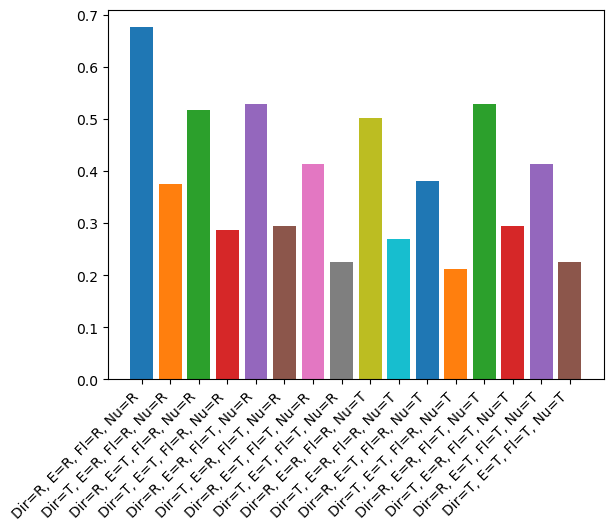

In [23]:
def plot_hesse_errors(method: int):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = sum(
            LnL(ref_event_rates[ch], expected[ch]) for ch in events.detected_channels
        )
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    dcp_err = fitter.hesse().errors["dcp"]
    plt.bar(
        f"Dir={direc_reco.name[0]}, E={energy_reco.name[0]}, Fl={flavor_disc.name[0]}, Nu={nunubar_disc.name[0]}",
        dcp_err,
    )
    plt.xticks(rotation=45, ha="right")


plt.figure()
for method in tqdm(range(0b0000, 0b10000)):
    plot_hesse_errors(method)
plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


  9%|▉         | 1/11 [00:31<05:14, 31.44s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 18%|█▊        | 2/11 [01:03<04:44, 31.57s/it]

...

 82%|████████▏ | 9/11 [04:47<01:04, 32.01s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 91%|█████████ | 10/11 [05:19<00:32, 32.09s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


100%|██████████| 11/11 [05:51<00:00, 31.91s/it]


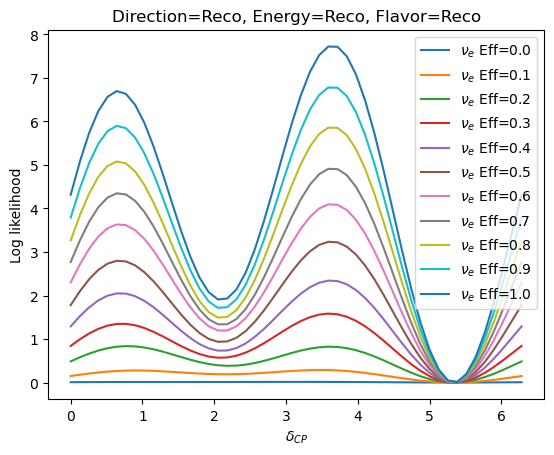

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuMu', 'NuTau']
Finished filling histograms...


  9%|▉         | 1/11 [00:23<03:51, 23.11s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 18%|█▊        | 2/11 [00:49<03:46, 25.17s/it]

...

 82%|████████▏ | 9/11 [03:56<00:53, 26.61s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 91%|█████████ | 10/11 [04:23<00:26, 26.61s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 11/11 [04:49<00:00, 26.35s/it]


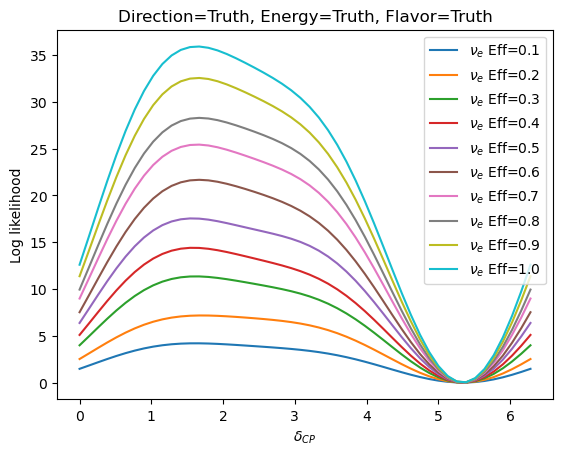

In [ ]:
def plot_nunubar_efficiencies(method: int, flavors: dict[Flavor, int | float]):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: flavors.get(Flavor.NuE, 1.0),
        Flavor.NuEBar: flavors.get(Flavor.NuEBar, 1.0),
        Flavor.NuMu: flavors.get(Flavor.NuMu, 1.0),
        Flavor.NuMuBar: flavors.get(Flavor.NuMuBar, 1.0),
        Flavor.NuTau: flavors.get(Flavor.NuTau, 1.0),
        Flavor.NuTauBar: flavors.get(Flavor.NuTauBar, 1.0),
        Flavor.NC: flavors.get(Flavor.NC, 1.0),
    }
    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    for ch, values in LnL_values.items():
        if ch not in flavors:
            continue

        plt.plot(
            sampling,
            values,
            label=f"{latex_names[ch]} Eff={efficiencies[ch]:.1f}",
        )

    plt.xlabel(r"$\delta_{CP}$")
    plt.ylabel("Log likelihood")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
    )


for method in [0b000, 0b111]:  # [all reco, all truth]
    plt.figure()
    for efficiency in tqdm(np.linspace(0, 1, 11)):
        plot_nunubar_efficiencies(method, {Flavor.NuE: efficiency})
    plt.legend()
    plt.show()

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


  9%|▉         | 1/11 [01:03<10:39, 63.97s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 18%|█▊        | 2/11 [02:09<09:41, 64.60s/it]

...

 82%|████████▏ | 9/11 [09:42<02:10, 65.06s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


 91%|█████████ | 10/11 [10:47<01:05, 65.00s/it]

Filling histograms...
Using the following detected output channels: ['NuMuBar', 'NuEBar', 'NC', 'NuE', 'NuMu']
Finished filling histograms...


100%|██████████| 11/11 [11:51<00:00, 64.73s/it]


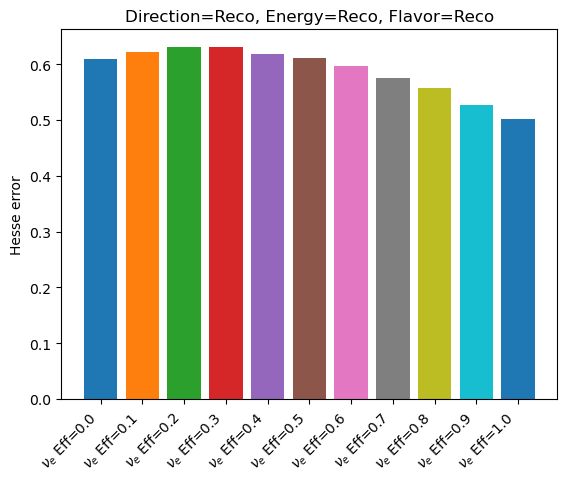

  0%|          | 0/11 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuMu', 'NuTau']
Finished filling histograms...


  9%|▉         | 1/11 [00:41<06:50, 41.08s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 18%|█▊        | 2/11 [01:28<06:42, 44.67s/it]

...

 82%|████████▏ | 9/11 [07:04<01:35, 47.95s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


 91%|█████████ | 10/11 [07:52<00:47, 47.92s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


100%|██████████| 11/11 [08:39<00:00, 47.18s/it]


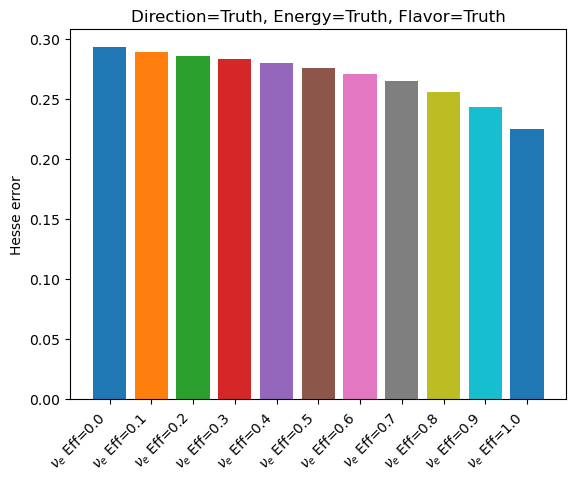

In [25]:
def plot_hesse_errors_nunubar_eff(
    method: int, flavor=Flavor.NuE, efficiency: float = 1.0
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)

    efficiencies = {
        Flavor.NuE: 1.0,
        Flavor.NuEBar: 1.0,
        Flavor.NuMu: 1.0,
        Flavor.NuMuBar: 1.0,
        Flavor.NuTau: 1.0,
        Flavor.NuTauBar: 1.0,
        Flavor.NC: 1.0,
    }
    efficiencies[flavor] = efficiency

    nunubar = FakeEfficiency(efficiencies)
    data_manager.set_nunubar_discrimination(Method.Efficiency, nunubar)
    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    # Gets the standard oscillation parameters
    pars = get_nufit(MH.Normal)
    # Compute the events with the standard oscillation parameters
    events.compute_osc(pars)
    # Saving the reference event rates
    ref_event_rates = {
        fl: events.detected_events(fl) for fl in events.detected_channels
    }

    LnL_values = {fl: [] for fl in events.detected_channels}

    # Sampling dcp values
    sampling = np.linspace(0, 2 * np.pi, 50)
    for val in sampling:
        # Setting the dcp value
        pars.dcp = val
        # Computing the events with the new dcp value
        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}

        # Computing the LnL values
        for ch in events.detected_channels:
            LnL_values[ch].append(LnL(ref_event_rates[ch], expected[ch]))

    # Converting the lists to numpy arrays
    LnL_values = {fl: np.array(values) for fl, values in LnL_values.items()}

    def loss(dm21, dm31, th12, th13, th23, dcp):
        pars = ROOT.OscPars()
        pars.dm21 = dm21
        pars.dm31 = dm31
        pars.th12 = th12
        pars.th13 = th13
        pars.th23 = th23
        pars.dcp = dcp

        events.compute_osc(pars)
        # Saving the expected event rates
        expected = {fl: events.detected_events(fl) for fl in events.detected_channels}
        total_loss = 0
        for ch in events.detected_channels:
            total_loss += LnL(ref_event_rates[ch], expected[ch])
        # print(total_loss)
        return total_loss

    nufit = get_nufit(MH.Normal)

    fitter = iminuit.Minuit(
        loss,
        dm21=nufit.dm21,
        dm31=nufit.dm31,
        th12=nufit.th12,
        th13=nufit.th13,
        th23=nufit.th23,
        dcp=nufit.dcp,
    )

    dcp_err = fitter.hesse().errors["dcp"]
    plt.bar(
        f"{latex_names[flavor]} Eff={efficiencies[flavor]:.1f}",
        dcp_err,
    )
    plt.xticks(rotation=45, ha="right")
    plt.title(
        f"Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}"
    )
    plt.ylabel("Hesse error")


for method in [0b000, 0b111]:
    plt.figure()
    for efficiency in tqdm(np.linspace(0, 1, 11)):
        plot_hesse_errors_nunubar_eff(method, Flavor.NuE, efficiency)
    plt.show()

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

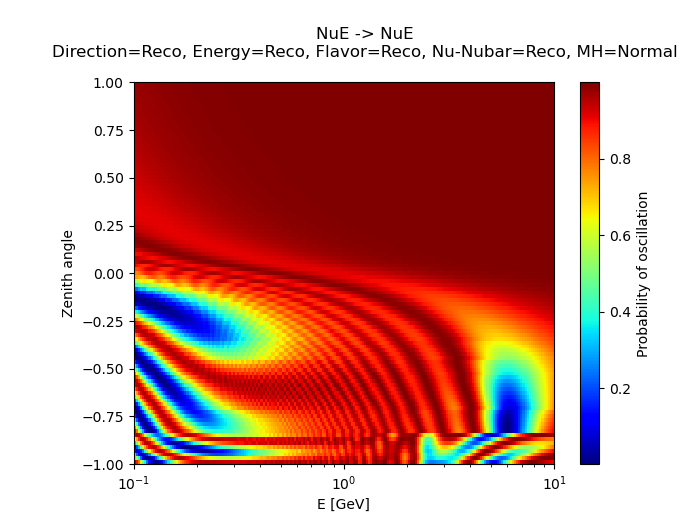

 50%|█████     | 1/2 [00:09<00:09,  9.22s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

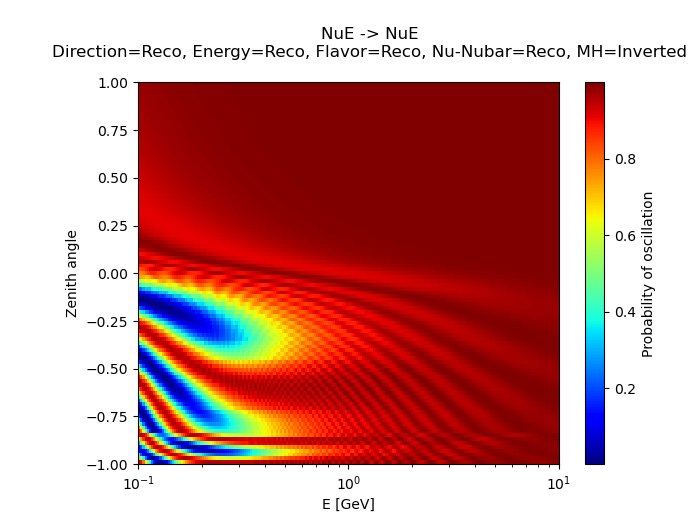

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

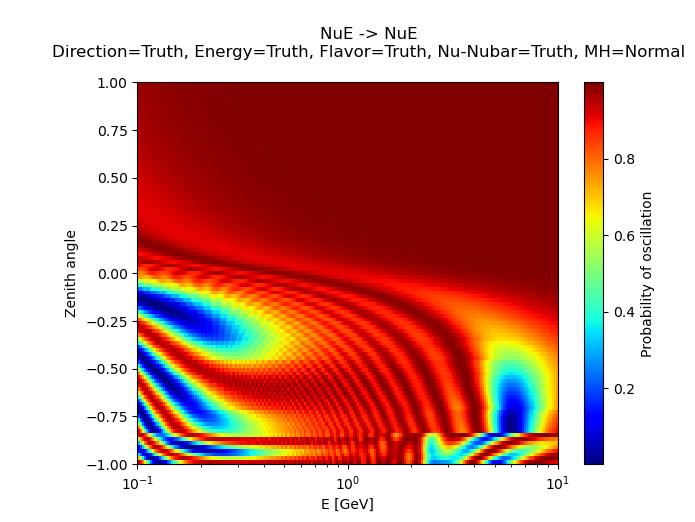

 50%|█████     | 1/2 [00:14<00:14, 14.40s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

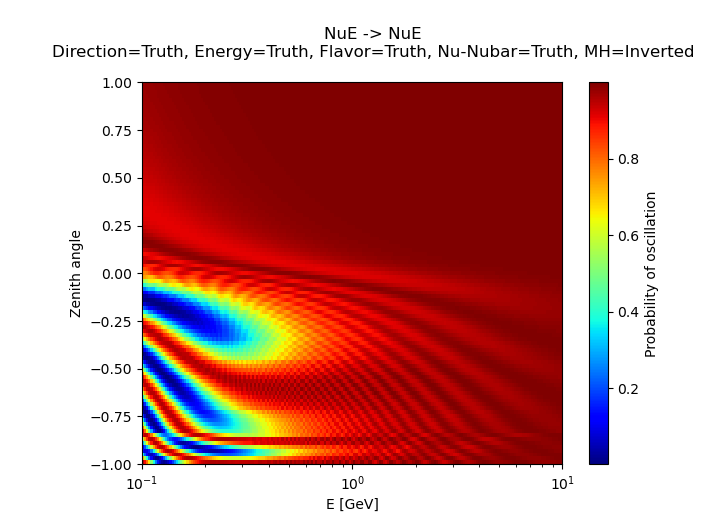

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

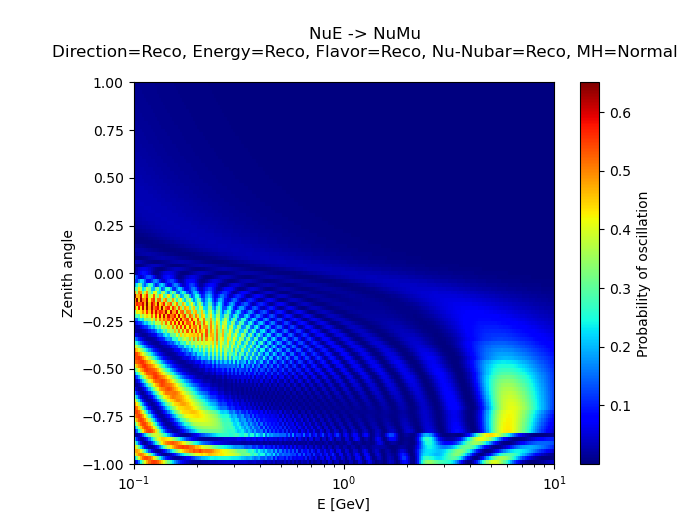

 50%|█████     | 1/2 [00:09<00:09,  9.61s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

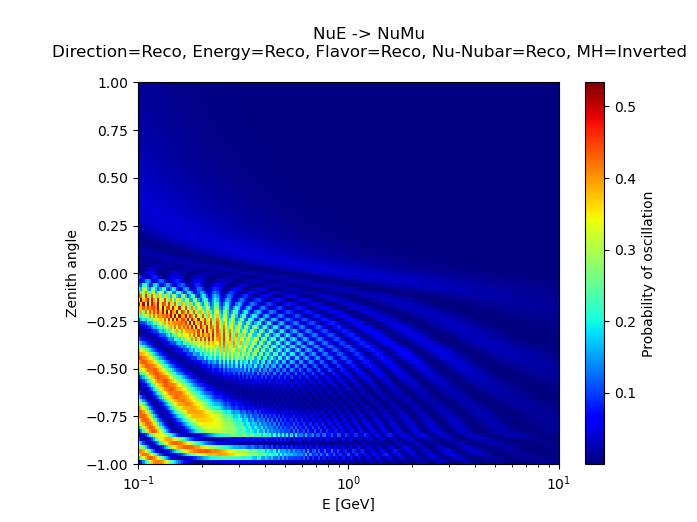

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

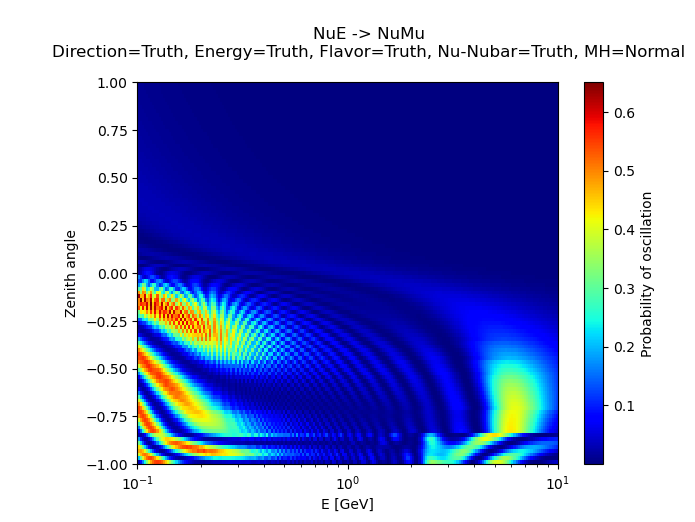

 50%|█████     | 1/2 [00:14<00:14, 14.36s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

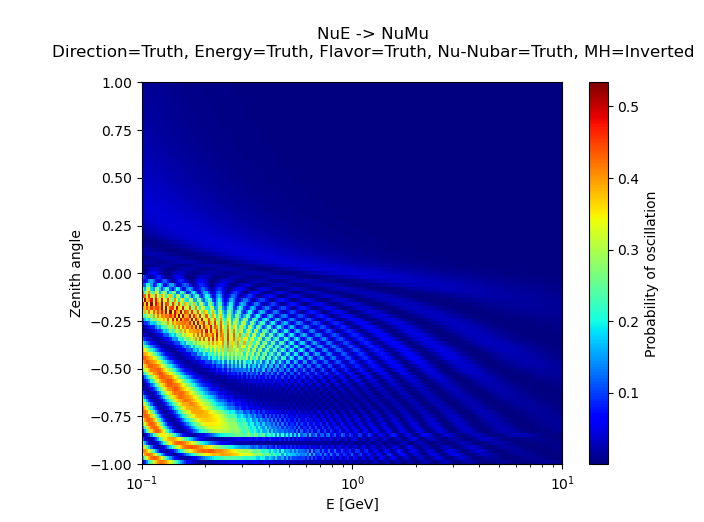

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

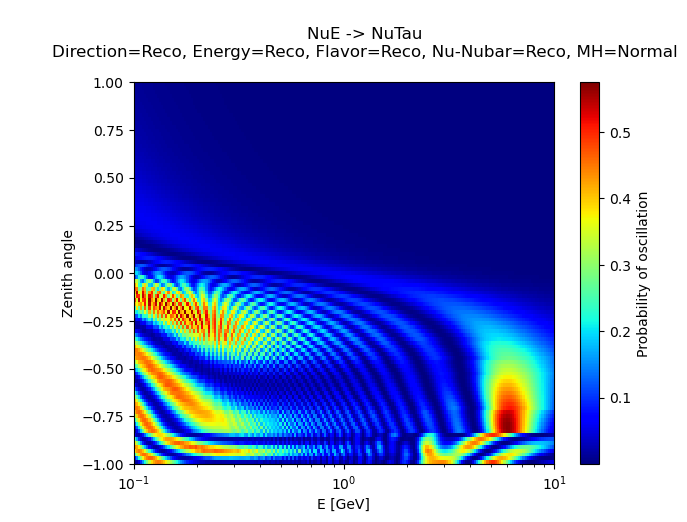

 50%|█████     | 1/2 [00:09<00:09,  9.58s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

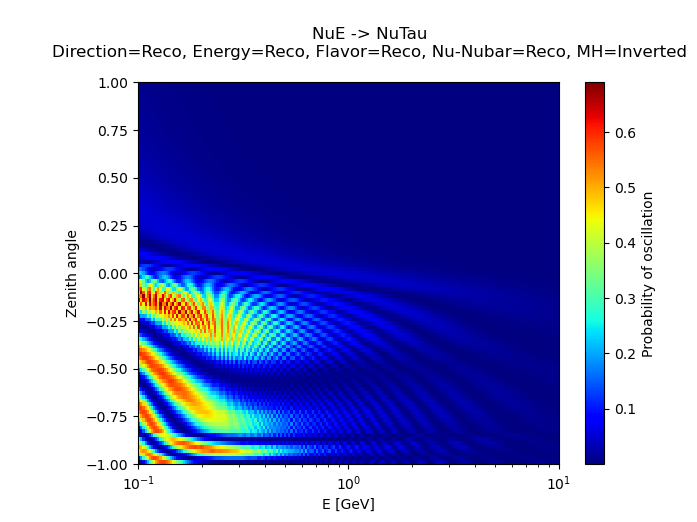

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

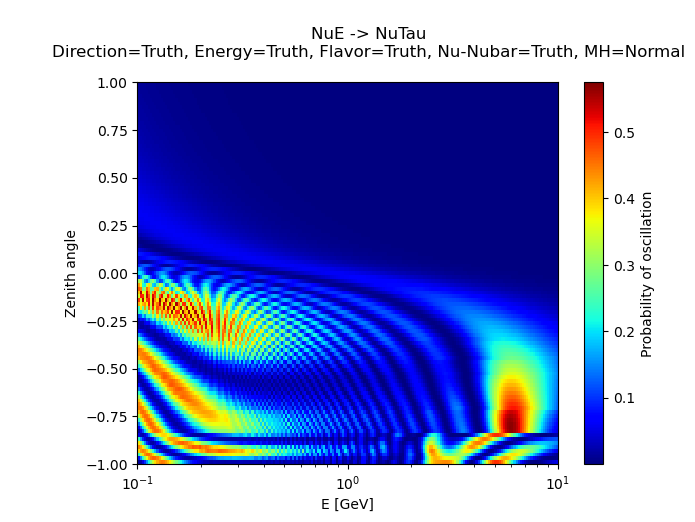

 50%|█████     | 1/2 [00:14<00:14, 14.35s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

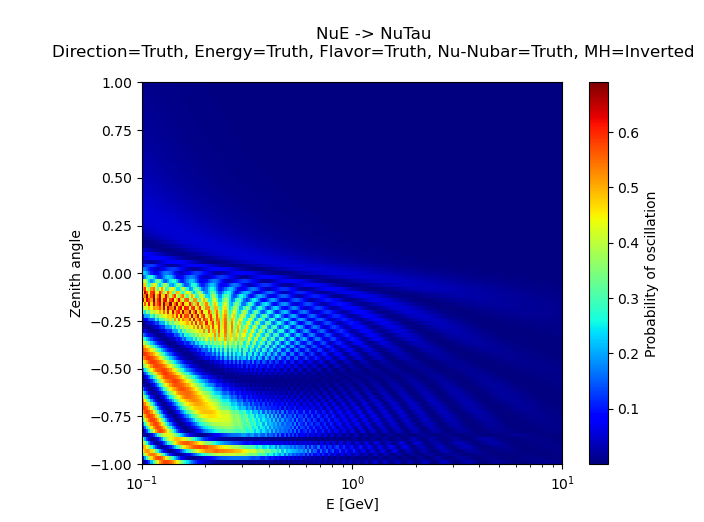

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

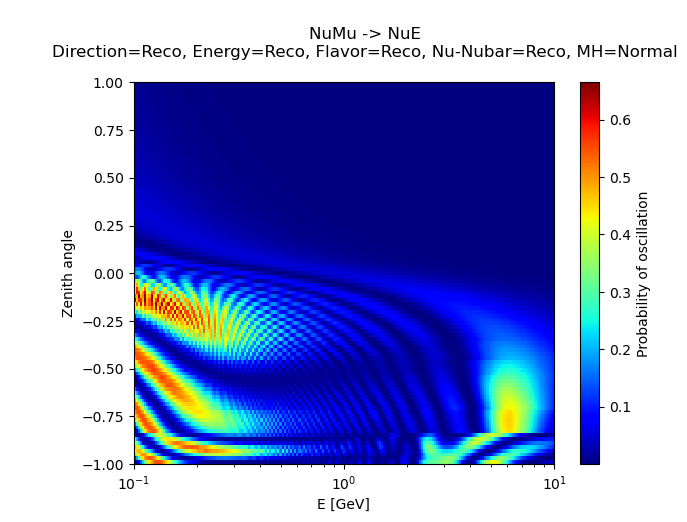

 50%|█████     | 1/2 [00:09<00:09,  9.18s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

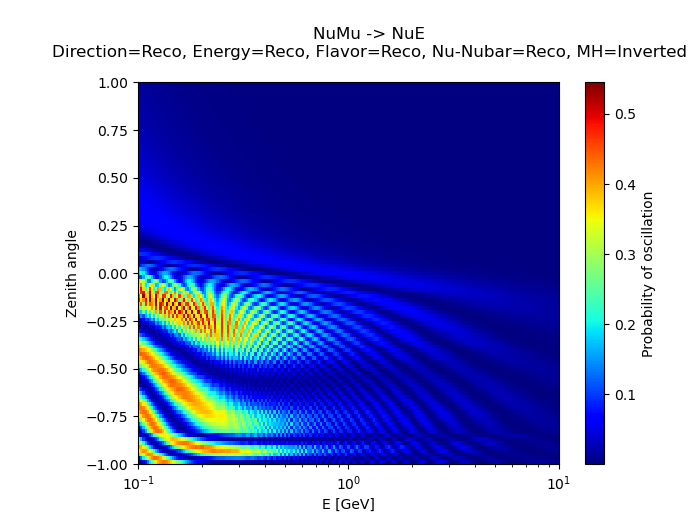

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

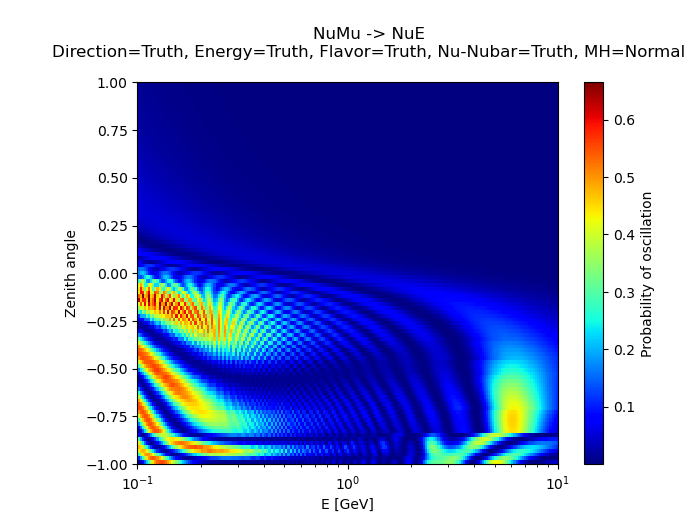

 50%|█████     | 1/2 [00:14<00:14, 14.60s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

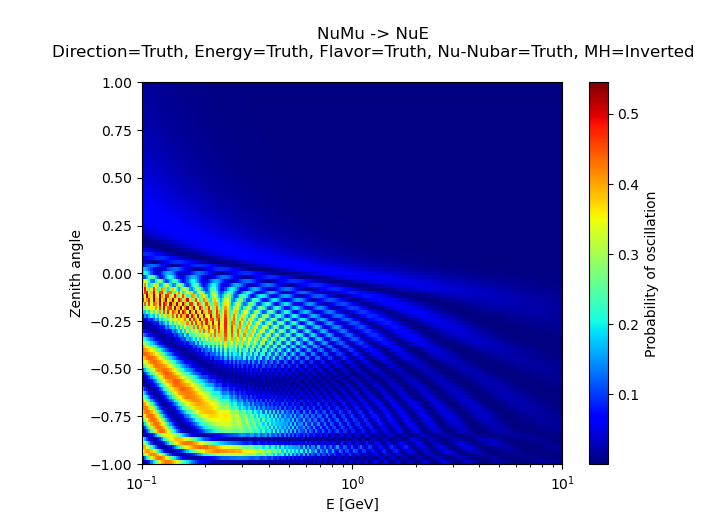

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

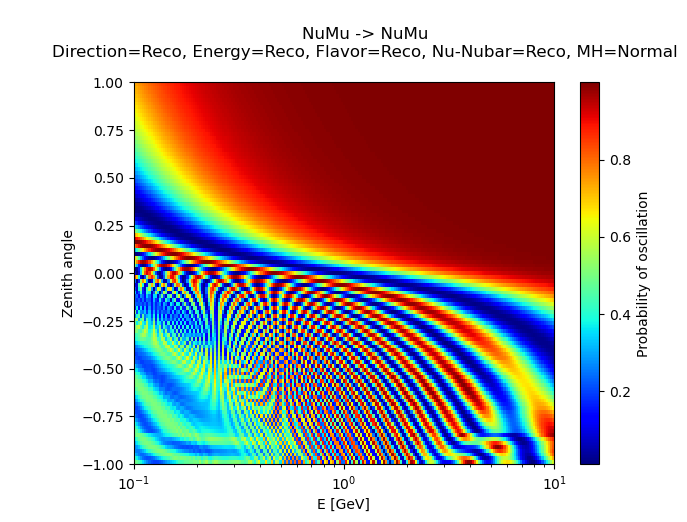

 50%|█████     | 1/2 [00:09<00:09,  9.21s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

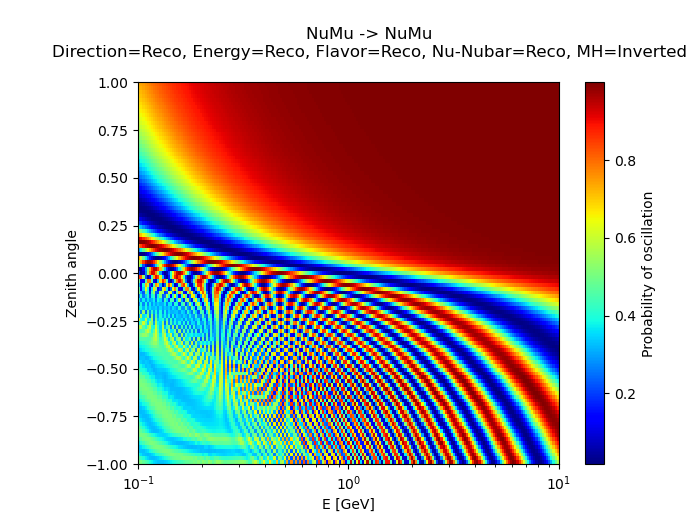

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

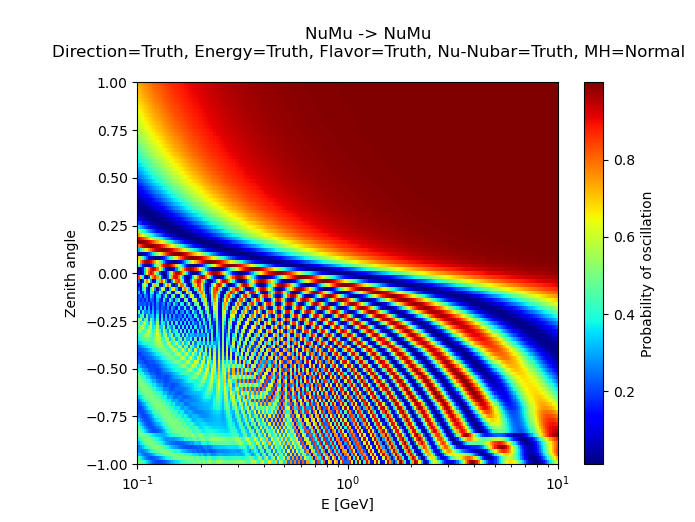

 50%|█████     | 1/2 [00:14<00:14, 14.52s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

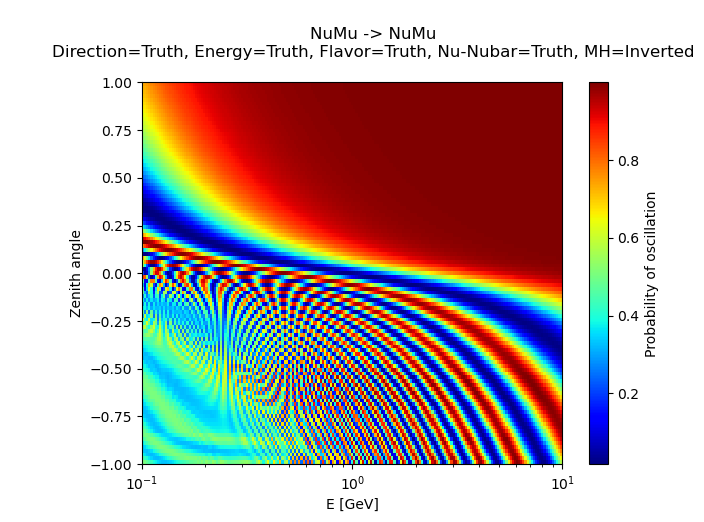

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

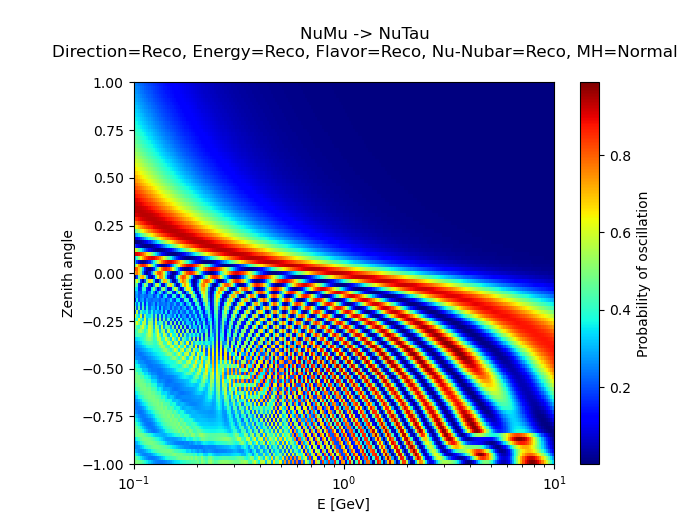

 50%|█████     | 1/2 [00:09<00:09,  9.37s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

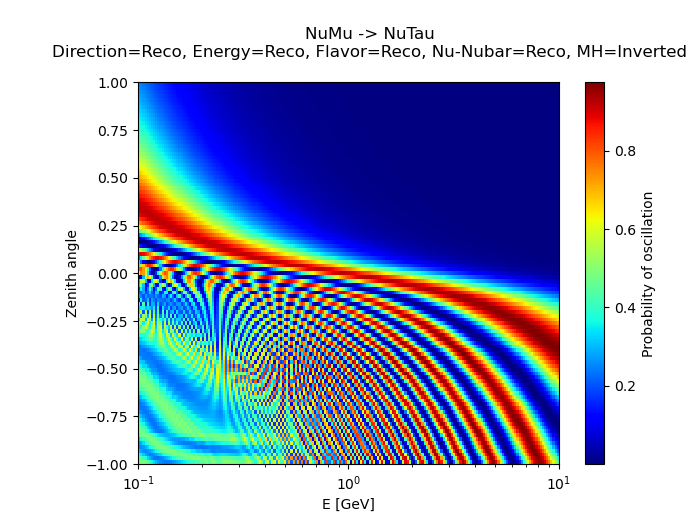

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

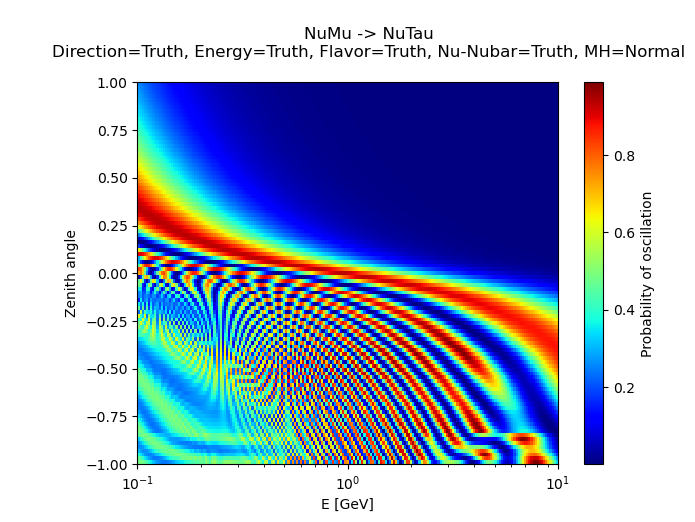

 50%|█████     | 1/2 [00:14<00:14, 14.42s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

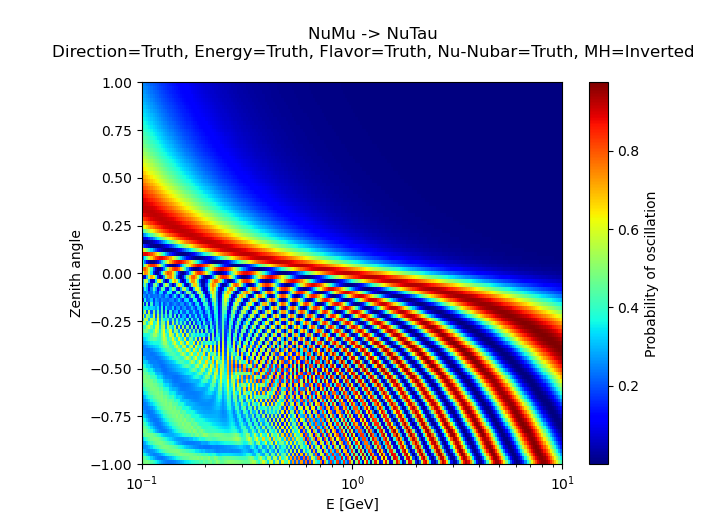

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

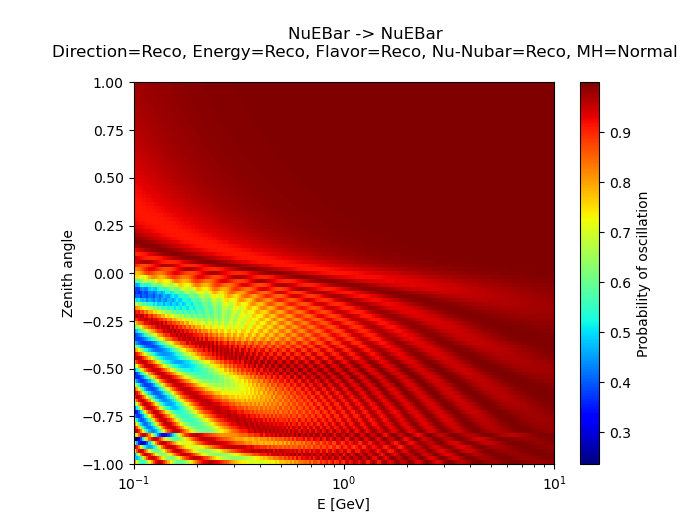

 50%|█████     | 1/2 [00:09<00:09,  9.29s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

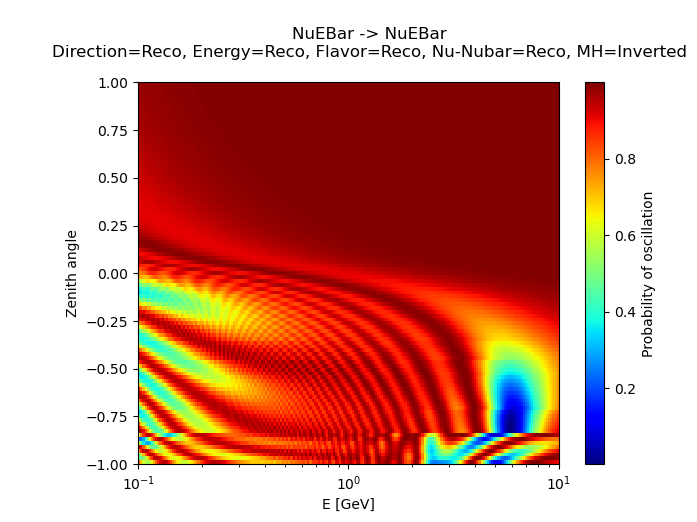

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

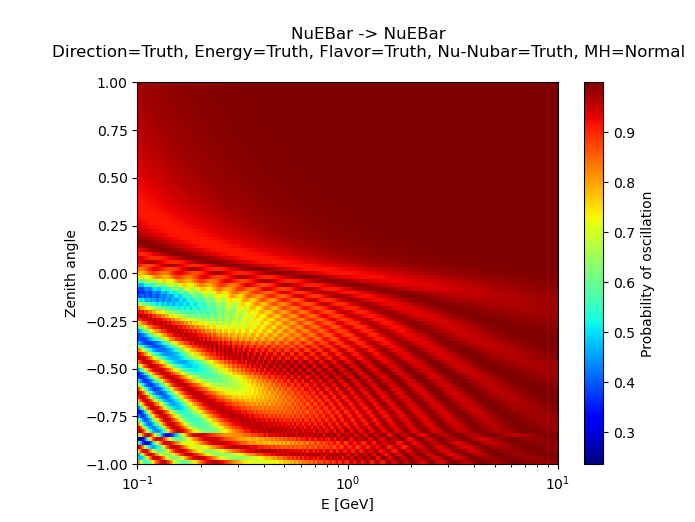

 50%|█████     | 1/2 [00:14<00:14, 14.62s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

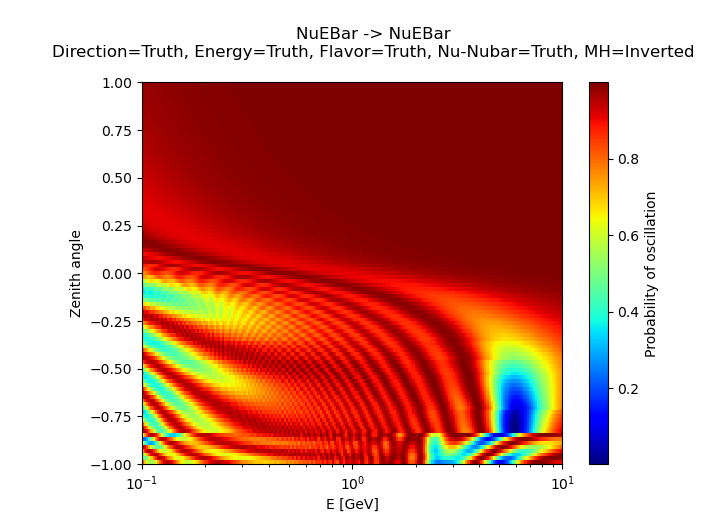

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

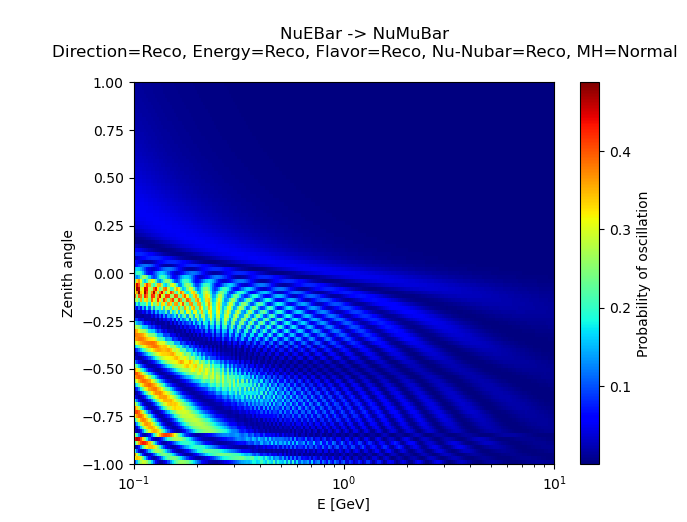

 50%|█████     | 1/2 [00:09<00:09,  9.25s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

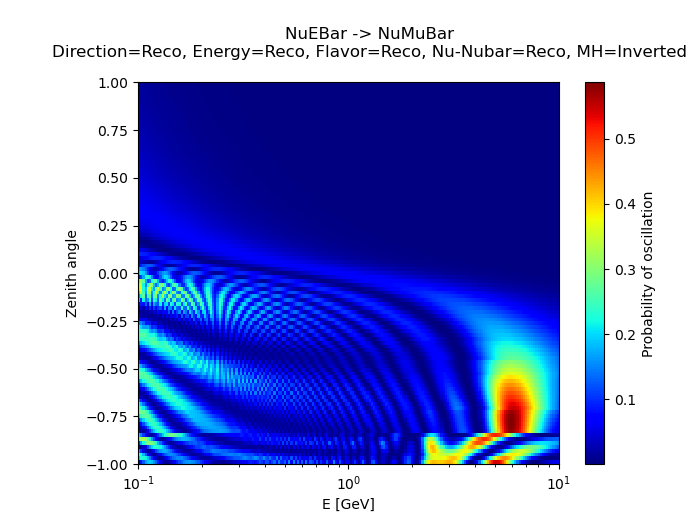

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

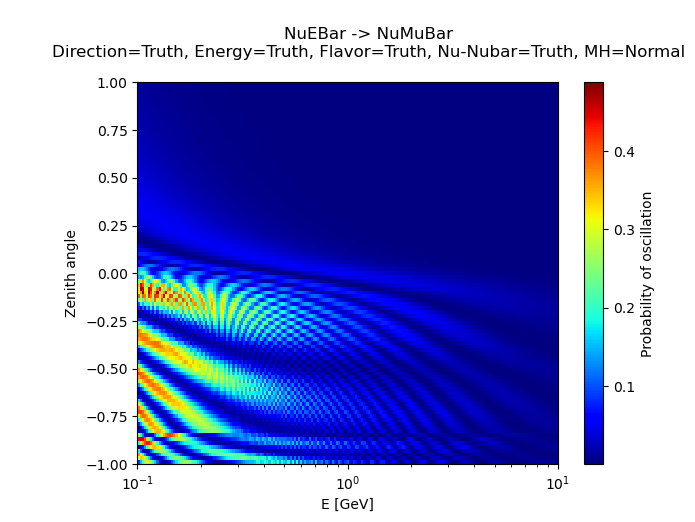

 50%|█████     | 1/2 [00:14<00:14, 14.73s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

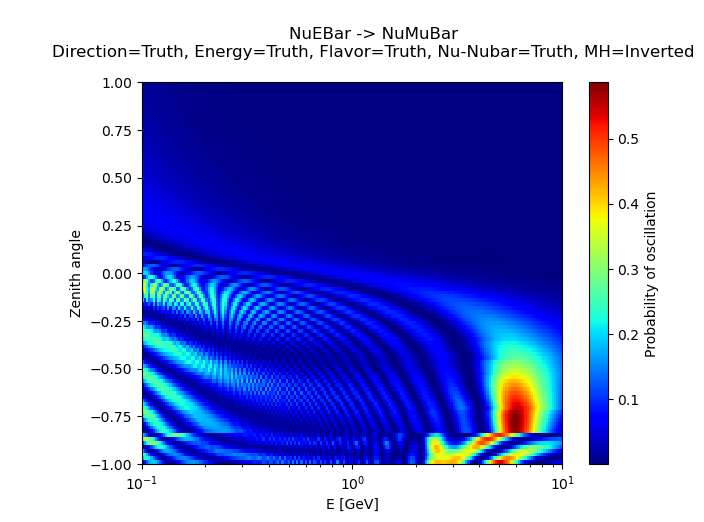

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

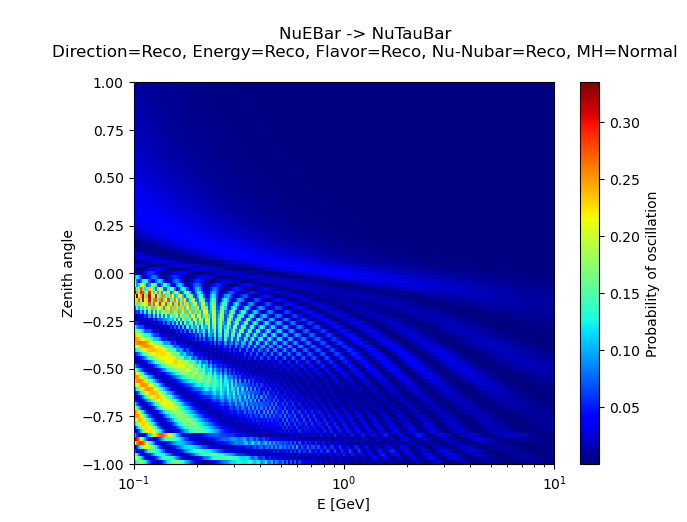

 50%|█████     | 1/2 [00:09<00:09,  9.09s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

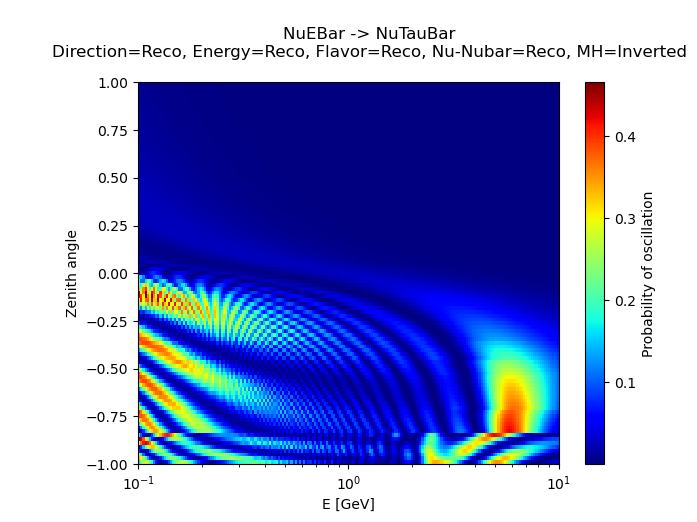

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

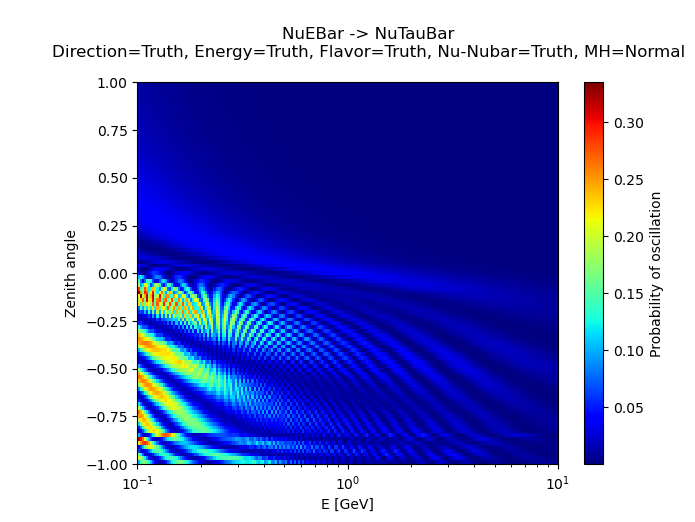

 50%|█████     | 1/2 [00:14<00:14, 14.42s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

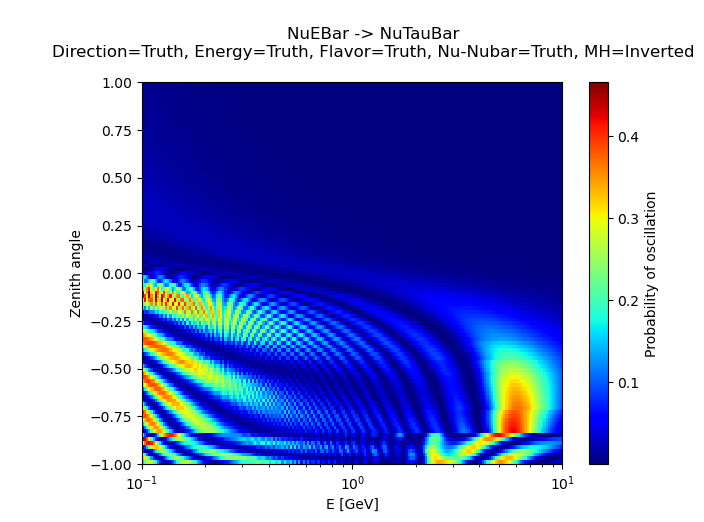

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

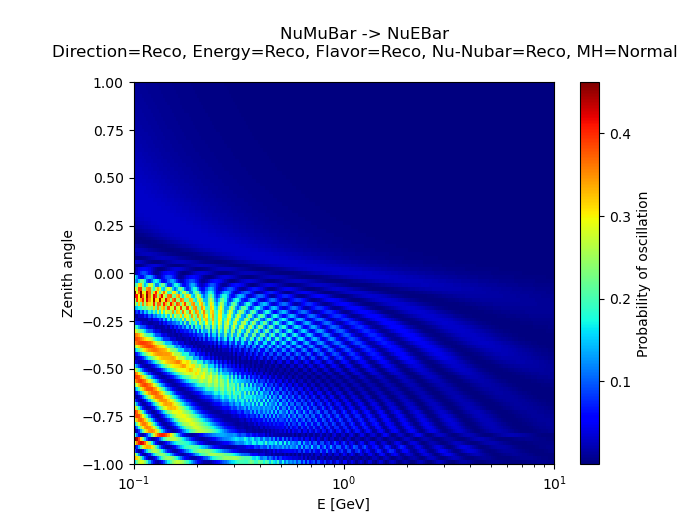

 50%|█████     | 1/2 [00:09<00:09,  9.67s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

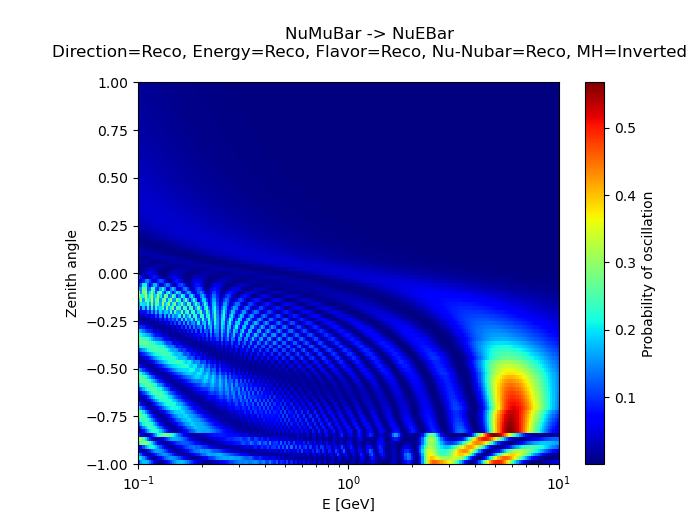

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

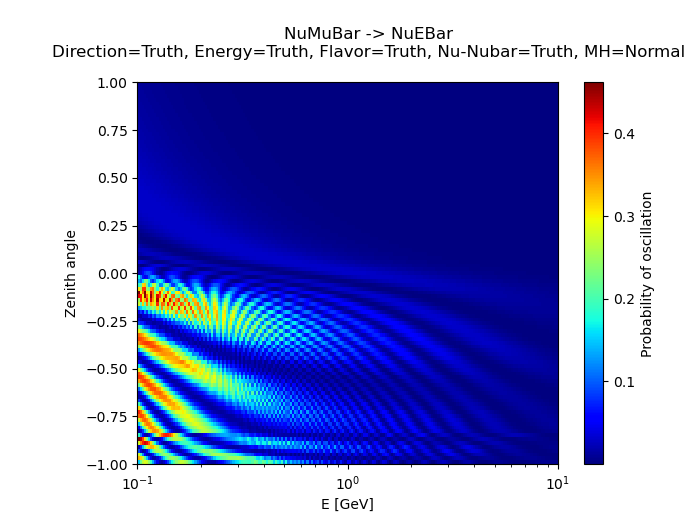

 50%|█████     | 1/2 [00:14<00:14, 14.43s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

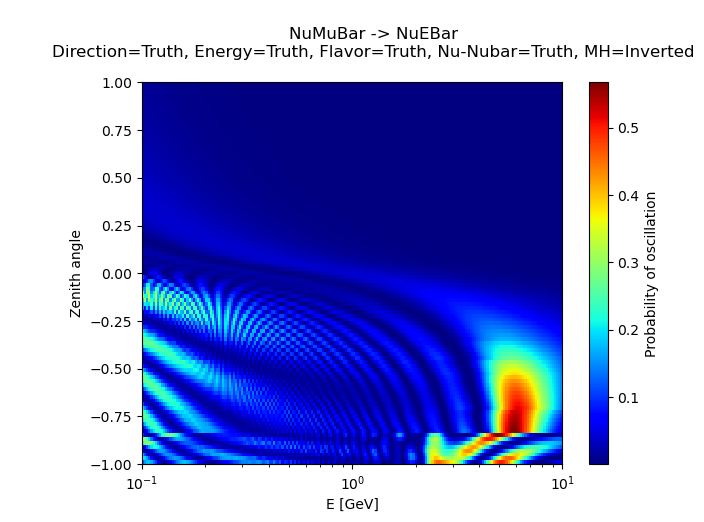

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

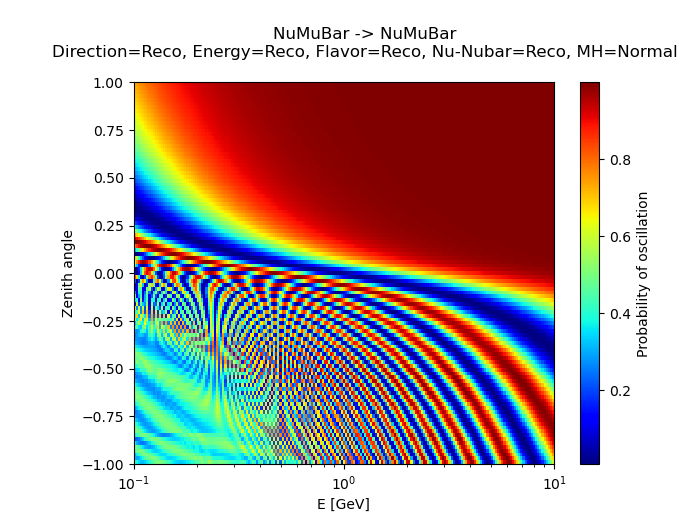

 50%|█████     | 1/2 [00:09<00:09,  9.37s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

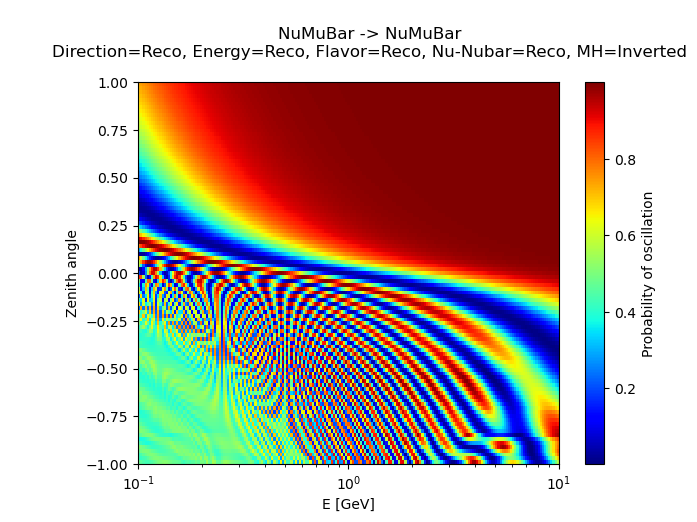

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

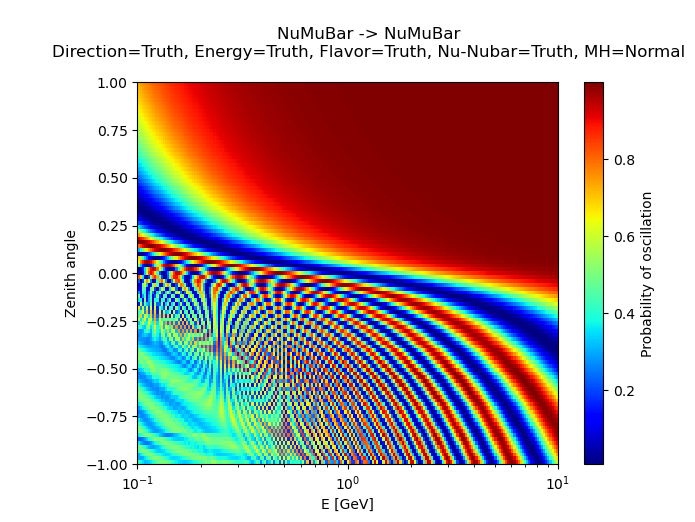

 50%|█████     | 1/2 [00:14<00:14, 14.28s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

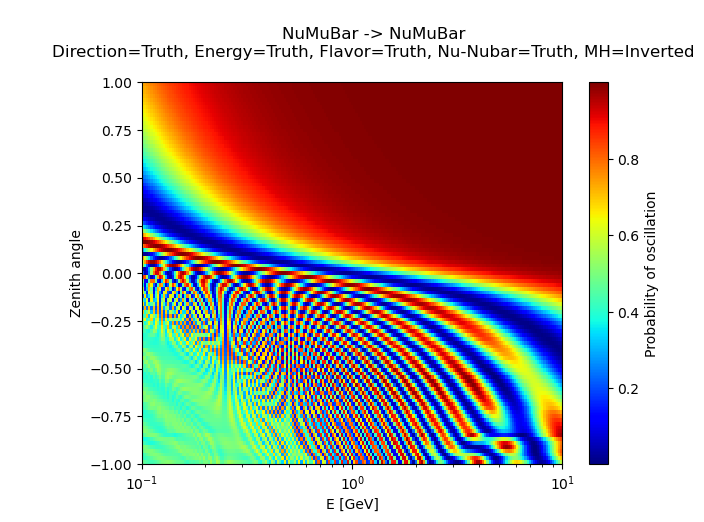

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

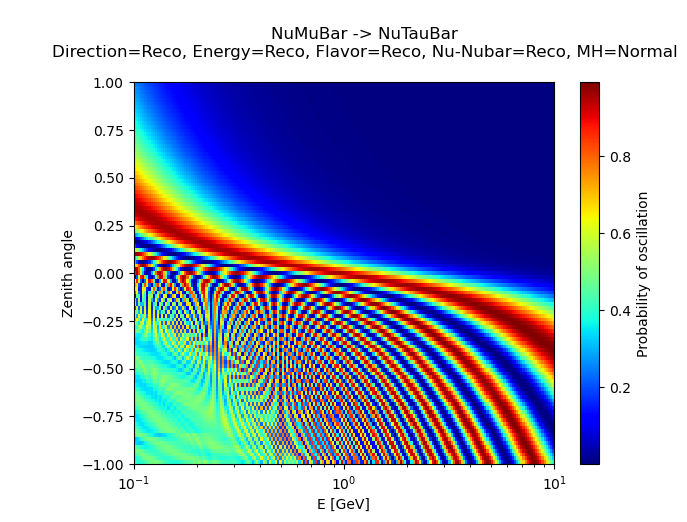

 50%|█████     | 1/2 [00:09<00:09,  9.39s/it]

Filling histograms...
Using the following detected output channels: ['NC', 'NuE', 'NuMu']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

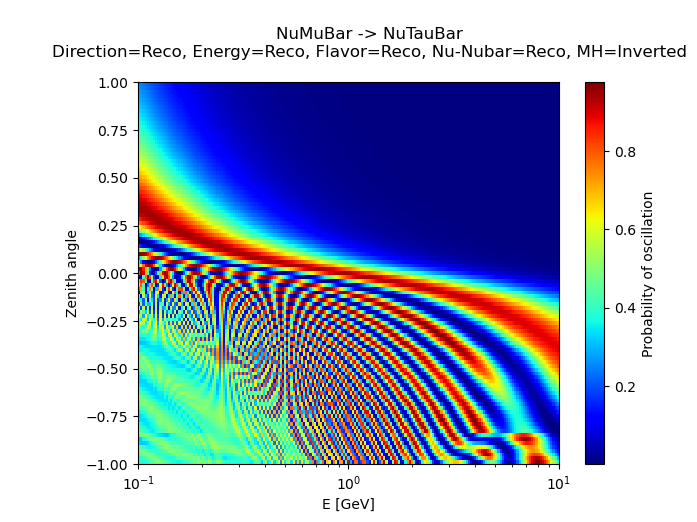

  0%|          | 0/2 [00:00<?, ?it/s]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

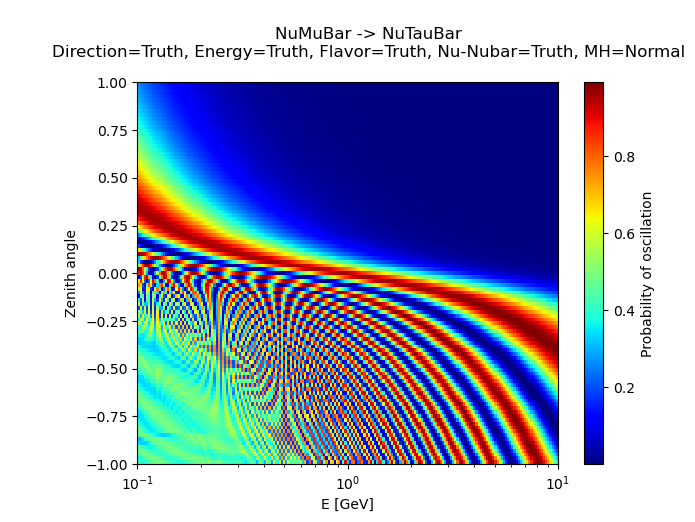

 50%|█████     | 1/2 [00:14<00:14, 14.62s/it]

Filling histograms...
Using the following detected output channels: ['NuTauBar', 'NuMuBar', 'NuEBar', 'NuE', 'NuMu', 'NuTau']
Finished filling histograms...


<Figure size 640x480 with 0 Axes>

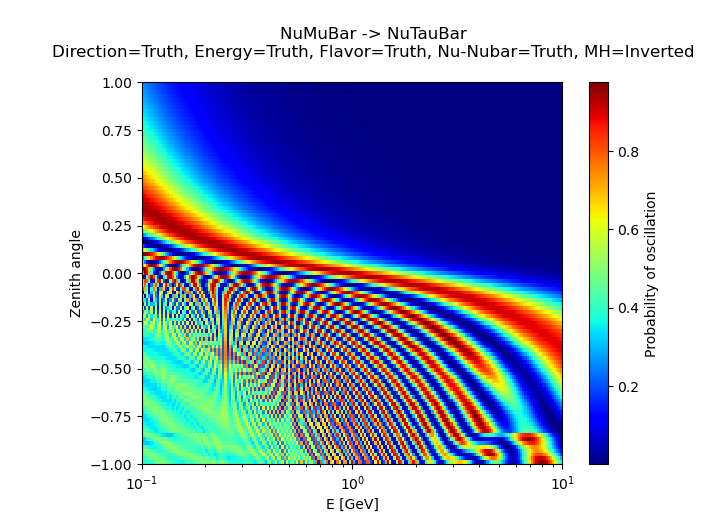

100%|██████████| 2/2 [00:29<00:00, 14.53s/it]


In [19]:
def plot_oscillograms(
    method: int, input_flavor: Flavor, output_flavor: Flavor, mass_hierarchy: MH
):
    direc_reco = Method.Truth if method & 1 << 0 else Method.Reco
    energy_reco = Method.Truth if method & 1 << 1 else Method.Reco
    flavor_disc = Method.Truth if method & 1 << 2 else Method.Reco
    nunubar_disc = Method.Truth if method & 1 << 3 else Method.Reco

    data_manager.set_direc_reco(direc_reco)
    data_manager.set_energy_reco(energy_reco)
    data_manager.set_flavor_discrimination(flavor_disc)
    data_manager.set_nunubar_discrimination(nunubar_disc)

    data = data_manager.prepare_data()

    # Creating the events distribution
    events = EventDistrib(data, Ebins, Czbins, Ebins_reco, Czbins_reco)

    nufit = get_nufit(mass_hierarchy)
    pars = ROOT.OscPars()
    pars.dm21 = nufit.dm21
    pars.dm31 = nufit.dm31
    pars.th12 = nufit.th12
    pars.th13 = nufit.th13
    pars.th23 = nufit.th23
    pars.dcp = nufit.dcp

    events.compute_osc(pars)
    fig = events.get_oscillogram(input_flavor, output_flavor)
    plt.colorbar(label="Probability of oscillation")
    plt.title(
        f"""
        {input_flavor.name} -> {output_flavor.name}
        Direction={direc_reco.name}, Energy={energy_reco.name}, Flavor={flavor_disc.name}, Nu-Nubar={nunubar_disc.name}, MH={mass_hierarchy.name}
        """
    )


for ifl, ofl in filter(lambda f: f[0] != Flavor.NC and f[1] != Flavor.NC, channels):
    for method in [0b0000, 0b1111]:
        for mh in tqdm(MH):
            plt.figure()
            plot_oscillograms(method, ifl, ofl, mh)
            plt.show()
